In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Pune_UHI_Final_Dataset.csv')

In [5]:
import os

print(os.getcwd())

d:\ISRO Hack\notebook\data


In [6]:
import os

for f in os.listdir():
    print(repr(f))
    

'EDA_UHI.ipynb'
'Pune_UHI_Final_Dataset.csv'


In [7]:
df = pd.read_csv('Pune_UHI_Final_Dataset.csv')

In [8]:
df.head()

,system:index,AirTemp,BuiltSurface,Elevation,LST,LULC,NDBI,NDVI,PopulationDensity,UrbanClass,WaterDistance,WindSpeed,.geo,Longitude,Latitude
0,0,28.635065,73,600,50.811608,50,0.054348,0.086455,129.102280,30,308.058436,2.199089,"{""type"":""Point"",""coordinates"":[73.855772057789...",73.855772,18.629668
1,1,26.607245,0,593,44.607901,40,0.003654,0.377969,0.000000,21,143.178211,1.532931,"{""type"":""Point"",""coordinates"":[73.712403405174...",73.712403,18.410803
2,2,27.794099,34,622,44.071272,50,-0.023955,0.267337,169.643249,30,315.753068,1.964554,"{""type"":""Point"",""coordinates"":[73.781171896135...",73.781172,18.513842
3,3,27.679385,0,594,45.958019,20,0.126663,0.429337,0.000000,21,355.105618,1.956267,"{""type"":""Point"",""coordinates"":[73.738424708592...",73.738425,18.692095
4,4,29.291838,0,656,55.695958,30,0.190257,0.164959,0.000000,11,344.093011,2.224560,"{""type"":""Point"",""coordinates"":[74.066627214229...",74.066627,18.585145


In [9]:
df.shape

(10000, 15)

In [10]:
# Check for missing values
df.isnull().sum()

system:index         0
AirTemp              0
BuiltSurface         0
Elevation            0
LST                  0
LULC                 0
NDBI                 0
NDVI                 0
PopulationDensity    0
UrbanClass           0
WaterDistance        0
WindSpeed            0
.geo                 0
Longitude            0
Latitude             0
dtype: int64

In [11]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
#check null values and dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   system:index       10000 non-null  int64  
 1   AirTemp            10000 non-null  float64
 2   BuiltSurface       10000 non-null  int64  
 3   Elevation          10000 non-null  int64  
 4   LST                10000 non-null  float64
 5   LULC               10000 non-null  int64  
 6   NDBI               10000 non-null  float64
 7   NDVI               10000 non-null  float64
 8   PopulationDensity  10000 non-null  float64
 9   UrbanClass         10000 non-null  int64  
 10  WaterDistance      10000 non-null  float64
 11  WindSpeed          10000 non-null  float64
 12  .geo               10000 non-null  str    
 13  Longitude          10000 non-null  float64
 14  Latitude           10000 non-null  float64
dtypes: float64(9), int64(5), str(1)
memory usage: 1.1 MB


In [13]:
#checking the number of unique values in each column
df.nunique()

system:index         10000
AirTemp                 20
BuiltSurface            98
Elevation              439
LST                   4056
LULC                     7
NDBI                  9885
NDVI                  9899
PopulationDensity     5081
UrbanClass               7
WaterDistance         2416
WindSpeed               20
.geo                 10000
Longitude            10000
Latitude              9999
dtype: int64

In [14]:
#check stats of the data
df.describe()

,system:index,AirTemp,BuiltSurface,Elevation,LST,LULC,NDBI,NDVI,PopulationDensity,UrbanClass,WaterDistance,WindSpeed,Longitude,Latitude
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,28.223431,10.776500,606.191600,48.861916,34.732000,0.057917,0.255765,49.358257,21.609300,420.296965,2.117834,73.899445,18.550268
std,2886.89568,0.646443,20.715517,74.299469,4.078493,14.707475,0.129456,0.183011,123.756108,7.923694,285.534768,0.195349,0.115124,0.086274
min,0.00000,26.607245,0.000000,518.000000,29.572031,10.000000,-0.512700,-0.990783,0.000000,11.000000,0.000000,1.532931,73.700018,18.400045
25%,2499.75000,27.794099,0.000000,563.000000,46.238297,30.000000,-0.003276,0.136836,0.000000,12.000000,200.249844,2.080543,73.800449,18.476013
50%,4999.50000,28.169428,0.000000,582.000000,48.885553,40.000000,0.081044,0.207567,1.718108,21.000000,375.898923,2.192060,73.900897,18.549474
75%,7499.25000,28.635065,12.000000,614.000000,51.783180,50.000000,0.145532,0.345911,31.929012,30.000000,585.234995,2.241366,73.999542,18.624600
max,9999.00000,29.291838,100.000000,1095.000000,61.216061,80.000000,0.983740,0.914452,1455.722656,30.000000,1564.672490,2.550084,74.099952,18.699981


In [15]:
# Exploring Data

print("Categories in 'LULC' variable: ", end="")
print(df['LULC'].unique())

print("\nCategories in 'UrbanClass' variable: ", end="")
print(df['UrbanClass'].unique())

print("\nUnique values in 'BuiltSurface' variable: ", end="")
print(df['BuiltSurface'].nunique())

print("\nUnique values in 'PopulationDensity' variable: ", end="")
print(df['PopulationDensity'].nunique())

print("\nUnique values in 'AirTemp' variable: ", end="")
print(df['AirTemp'].nunique())

print("\nUnique values in 'LST' variable: ", end="")
print(df['LST'].nunique())

print("\nUnique values in 'NDBI' variable: ", end="")
print(df['NDBI'].nunique())

print("\nUnique values in 'NDVI' variable: ", end="")
print(df['NDVI'].nunique())

print("\nUnique values in 'Elevation' variable: ", end="")
print(df['Elevation'].nunique())

print("\nUnique values in 'WaterDistance' variable: ", end="")
print(df['WaterDistance'].nunique())

print("\nUnique values in 'WindSpeed' variable: ", end="")
print(df['WindSpeed'].nunique())

Categories in 'LULC' variable: [50 40 20 30 10 80 60]

Categories in 'UrbanClass' variable: [30 21 11 12 22 23 13]

Unique values in 'BuiltSurface' variable: 98

Unique values in 'PopulationDensity' variable: 5081

Unique values in 'AirTemp' variable: 20

Unique values in 'LST' variable: 4056

Unique values in 'NDBI' variable: 9885

Unique values in 'NDVI' variable: 9899

Unique values in 'Elevation' variable: 439

Unique values in 'WaterDistance' variable: 2416

Unique values in 'WindSpeed' variable: 20


In [16]:
# Define numerical and categorical columns

categorical_features = ['LULC', 'UrbanClass']

numerical_features = [
    'AirTemp',
    'BuiltSurface',
    'Elevation',
    'LST',
    'NDBI',
    'NDVI',
    'PopulationDensity',
    'WaterDistance',
    'WindSpeed',
    'Longitude',
    'Latitude'
]

# Print columns

print('We have {} numerical features : {}'.format(
    len(numerical_features), numerical_features))

print('\nWe have {} categorical features : {}'.format(
    len(categorical_features), categorical_features))

We have 11 numerical features : ['AirTemp', 'BuiltSurface', 'Elevation', 'LST', 'NDBI', 'NDVI', 'PopulationDensity', 'WaterDistance', 'WindSpeed', 'Longitude', 'Latitude']

We have 2 categorical features : ['LULC', 'UrbanClass']


In [17]:
# Feature Engineering

# Urban Heat Island Intensity
df['UHI_Intensity'] = df['LST'] - df['AirTemp']

# Built-up vs Vegetation Balance
df['Built_Veg_Ratio'] = df['NDBI'] - df['NDVI']

# Relative Built Surface Percentage
df['BuiltSurface_Percent'] = (df['BuiltSurface'] / df['BuiltSurface'].max()) * 100

# Combined Environmental Stress Index
df['Env_Stress_Index'] = (
    df['NDBI'] +
    df['PopulationDensity'] / df['PopulationDensity'].max() -
    df['NDVI']
)

# Display first few rows
df.head()

,system:index,AirTemp,BuiltSurface,Elevation,LST,LULC,NDBI,NDVI,PopulationDensity,UrbanClass,WaterDistance,WindSpeed,.geo,Longitude,Latitude,UHI_Intensity,Built_Veg_Ratio,BuiltSurface_Percent,Env_Stress_Index
0,0,28.635065,73,600,50.811608,50,0.054348,0.086455,129.102280,30,308.058436,2.199089,"{""type"":""Point"",""coordinates"":[73.855772057789...",73.855772,18.629668,22.176543,-0.032108,73.0,0.056579
1,1,26.607245,0,593,44.607901,40,0.003654,0.377969,0.000000,21,143.178211,1.532931,"{""type"":""Point"",""coordinates"":[73.712403405174...",73.712403,18.410803,18.000657,-0.374315,0.0,-0.374315
2,2,27.794099,34,622,44.071272,50,-0.023955,0.267337,169.643249,30,315.753068,1.964554,"{""type"":""Point"",""coordinates"":[73.781171896135...",73.781172,18.513842,16.277173,-0.291291,34.0,-0.174756
3,3,27.679385,0,594,45.958019,20,0.126663,0.429337,0.000000,21,355.105618,1.956267,"{""type"":""Point"",""coordinates"":[73.738424708592...",73.738425,18.692095,18.278635,-0.302674,0.0,-0.302674
4,4,29.291838,0,656,55.695958,30,0.190257,0.164959,0.000000,11,344.093011,2.224560,"{""type"":""Point"",""coordinates"":[74.066627214229...",74.066627,18.585145,26.404121,0.025299,0.0,0.025299


In [18]:
# Count locations with very high values

high_lst = df[df['LST'] == df['LST'].max()].shape[0]
high_ndvi = df[df['NDVI'] == df['NDVI'].max()].shape[0]
high_ndbi = df[df['NDBI'] == df['NDBI'].max()].shape[0]
high_pop_density = df[df['PopulationDensity'] == df['PopulationDensity'].max()].shape[0]

print(f'Number of locations with maximum LST: {high_lst}')
print(f'Number of locations with maximum NDVI: {high_ndvi}')
print(f'Number of locations with maximum NDBI: {high_ndbi}')
print(f'Number of locations with maximum Population Density: {high_pop_density}')

Number of locations with maximum LST: 1
Number of locations with maximum NDVI: 1
Number of locations with maximum NDBI: 1
Number of locations with maximum Population Density: 1


In [19]:
# Hotspot Analysis

hotspot_lst = df[df['LST'] > df['LST'].quantile(0.95)].shape[0]
high_ndbi = df[df['NDBI'] > df['NDBI'].quantile(0.95)].shape[0]
high_ndvi = df[df['NDVI'] > df['NDVI'].quantile(0.95)].shape[0]
high_pop_density = df[df['PopulationDensity'] > df['PopulationDensity'].quantile(0.95)].shape[0]

print(f'Number of hotspot locations (Top 5% LST): {hotspot_lst}')
print(f'Number of highly built-up locations (Top 5% NDBI): {high_ndbi}')
print(f'Number of highly vegetated locations (Top 5% NDVI): {high_ndvi}')
print(f'Number of highly populated locations (Top 5% Population Density): {high_pop_density}')

Number of hotspot locations (Top 5% LST): 500
Number of highly built-up locations (Top 5% NDBI): 500
Number of highly vegetated locations (Top 5% NDVI): 500
Number of highly populated locations (Top 5% Population Density): 500


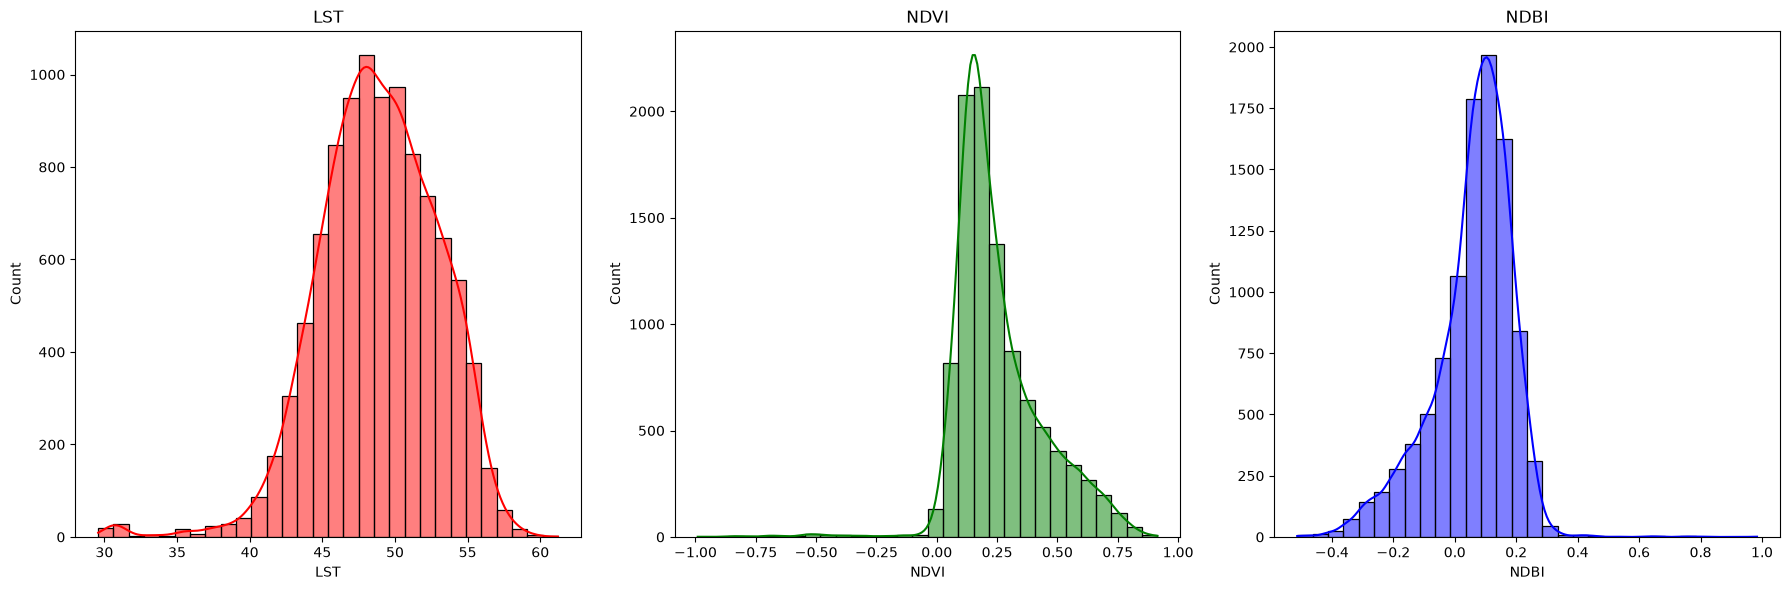

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

plt.subplot(131)
sns.histplot(data=df, x='LST', bins=30, kde=True, color='red')
plt.title('LST')

plt.subplot(132)
sns.histplot(data=df, x='NDVI', bins=30, kde=True, color='green')
plt.title('NDVI')

plt.subplot(133)
sns.histplot(data=df, x='NDBI', bins=30, kde=True, color='blue')
plt.title('NDBI')

plt.tight_layout()
plt.show()

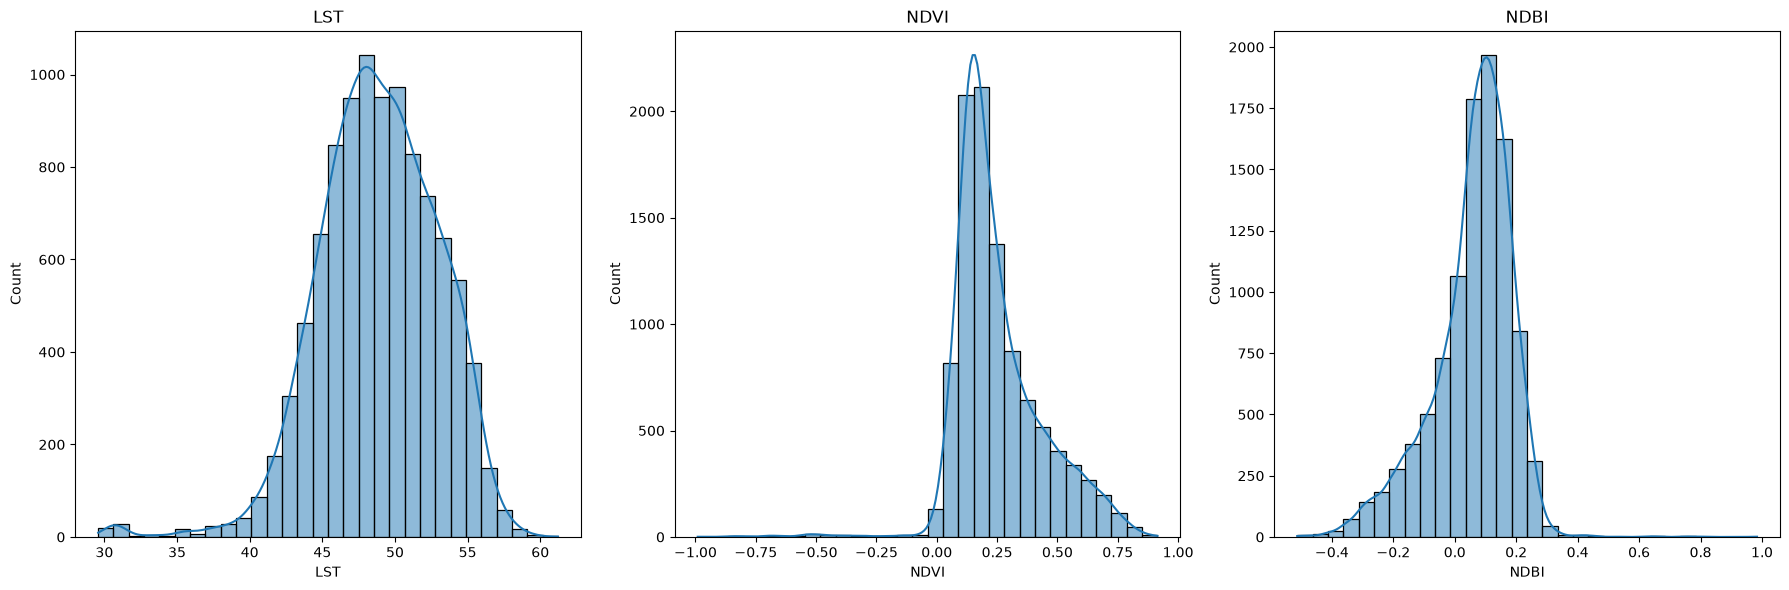

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

plt.subplot(131)
sns.histplot(data=df, x='LST', bins=30, kde=True)
plt.title('LST')

plt.subplot(132)
sns.histplot(data=df, x='NDVI', bins=30, kde=True)
plt.title('NDVI')

plt.subplot(133)
sns.histplot(data=df, x='NDBI', bins=30, kde=True)
plt.title('NDBI')

plt.tight_layout()
plt.show()

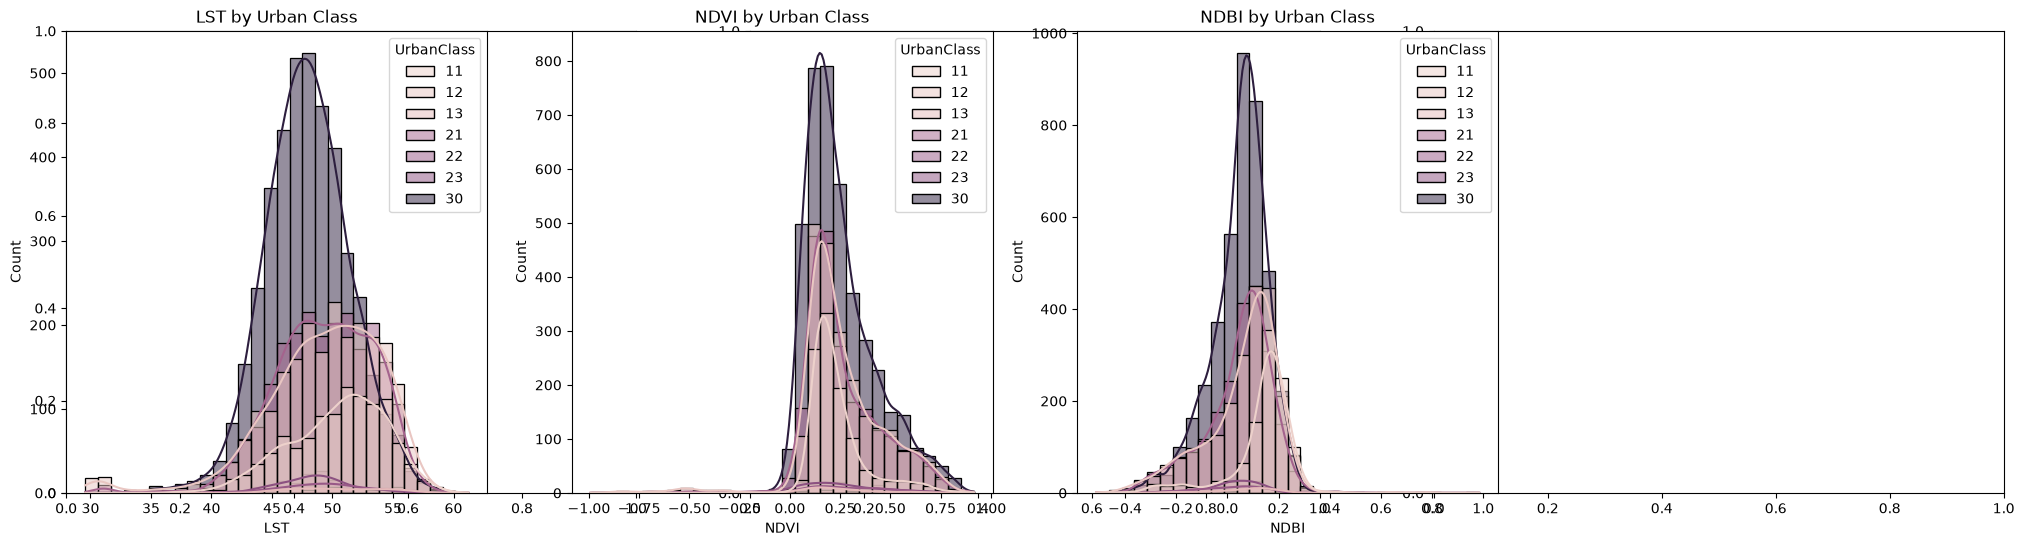

In [22]:
plt.subplots(1,3,figsize=(25,6))

plt.subplot(141)
sns.histplot(data=df, x='LST', bins=30, kde=True, hue='UrbanClass')
plt.title('LST by Urban Class')

plt.subplot(142)
sns.histplot(data=df, x='NDVI', bins=30, kde=True, hue='UrbanClass')
plt.title('NDVI by Urban Class')

plt.subplot(143)
sns.histplot(data=df, x='NDBI', bins=30, kde=True, hue='UrbanClass')
plt.title('NDBI by Urban Class')

plt.show()

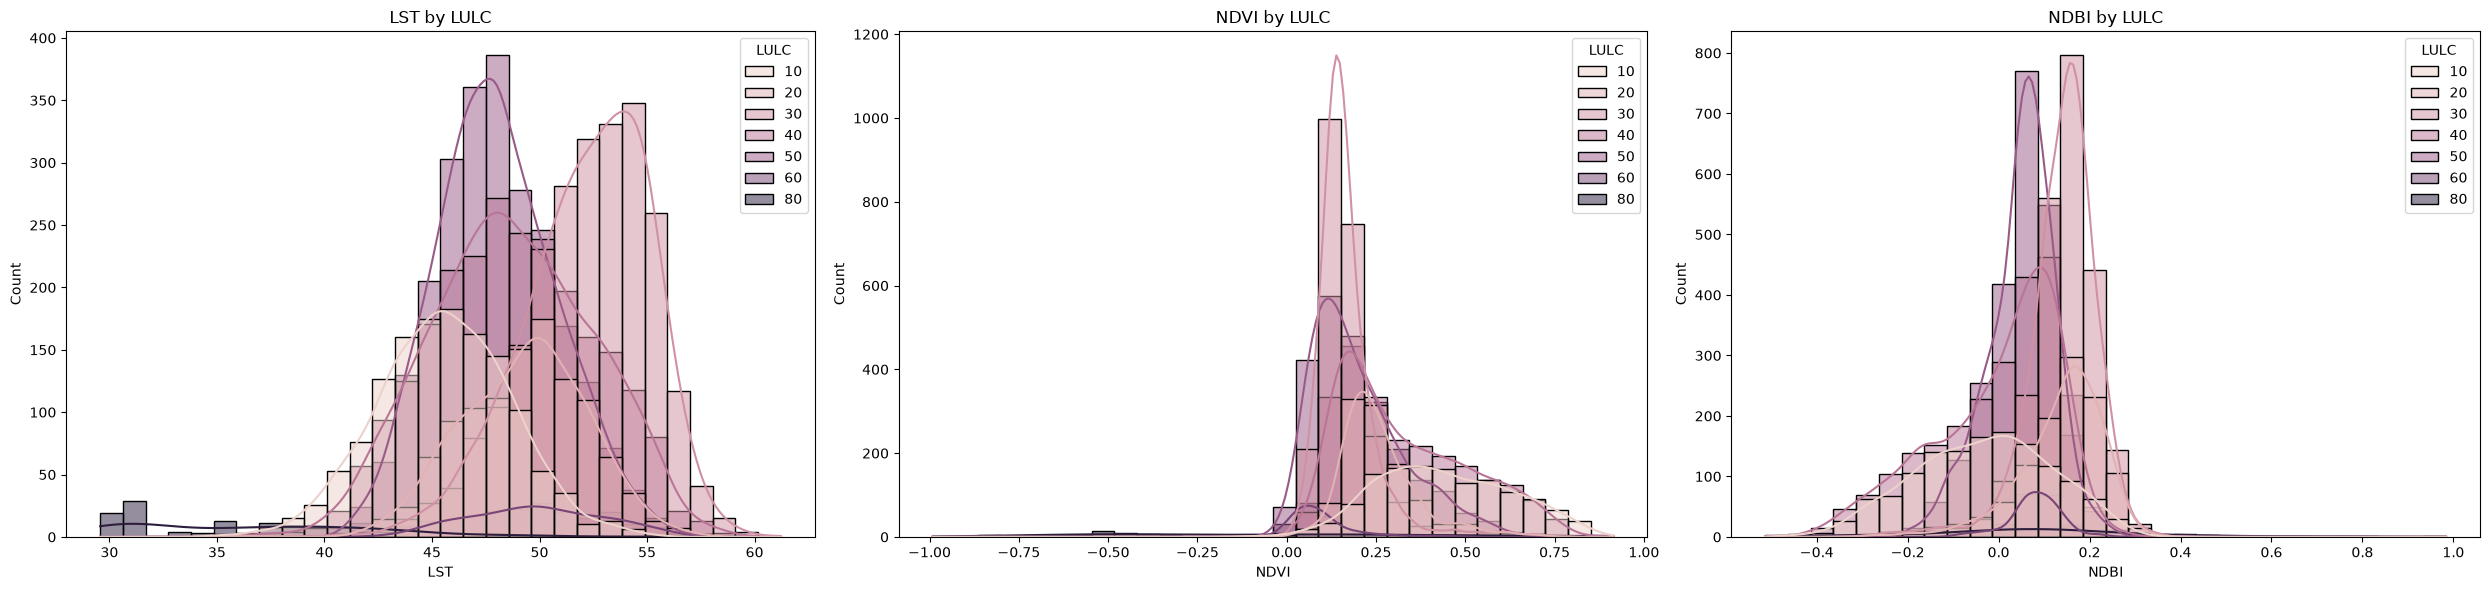

In [24]:
plt.subplots(1,3,figsize=(25,6))

plt.subplot(131)
sns.histplot(data=df, x='LST', bins=30, kde=True, hue='LULC')
plt.title('LST by LULC')

plt.subplot(132)
sns.histplot(data=df, x='NDVI', bins=30, kde=True, hue='LULC')
plt.title('NDVI by LULC')

plt.subplot(133)
sns.histplot(data=df, x='NDBI', bins=30, kde=True, hue='LULC')
plt.title('NDBI by LULC')

plt.tight_layout()
plt.show()

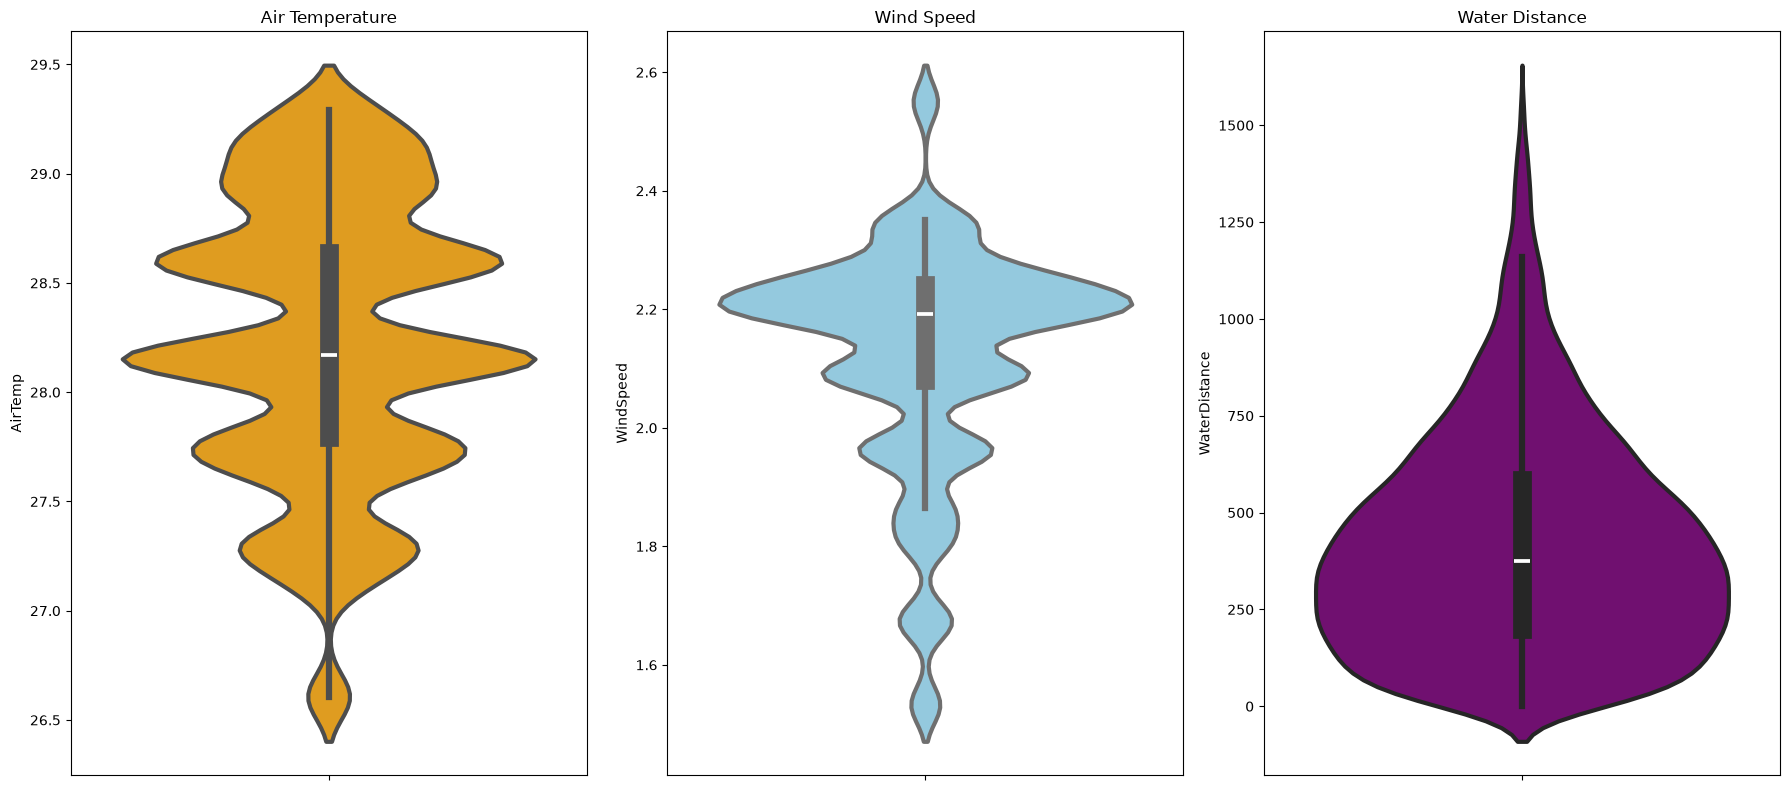

In [27]:
plt.figure(figsize=(18, 8))

plt.subplot(131)
plt.title('Air Temperature')
sns.violinplot(y='AirTemp', data=df, color='orange', linewidth=3)

plt.subplot(132)
plt.title('Wind Speed')
sns.violinplot(y='WindSpeed', data=df, color='skyblue', linewidth=3)

plt.subplot(133)
plt.title('Water Distance')
sns.violinplot(y='WaterDistance', data=df, color='purple', linewidth=3)

plt.tight_layout()
plt.show()

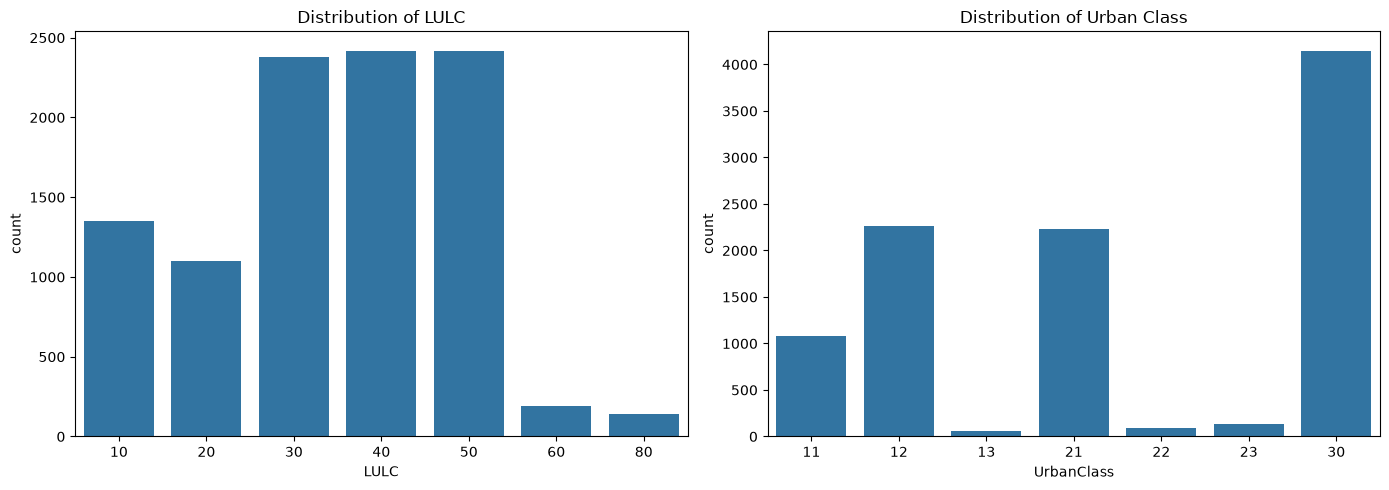

In [29]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plt.subplot(121)
sns.countplot(data=df, x='LULC')
plt.title('Distribution of LULC')

plt.subplot(122)
sns.countplot(data=df, x='UrbanClass')
plt.title('Distribution of Urban Class')

plt.tight_layout()
plt.show()

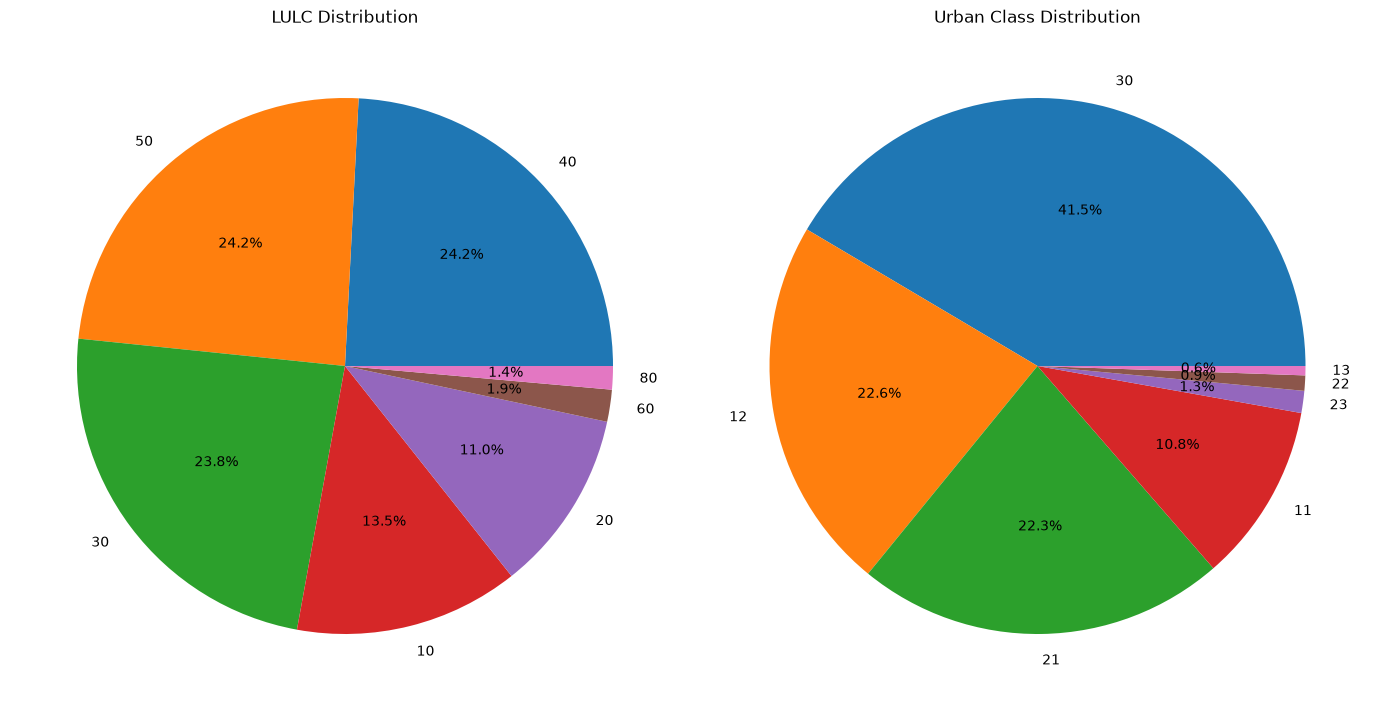

In [31]:
fig, ax = plt.subplots(1,2, figsize=(14,7))

df['LULC'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=ax[0]
)
ax[0].set_title('LULC Distribution')
ax[0].set_ylabel('')

df['UrbanClass'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=ax[1]
)
ax[1].set_title('Urban Class Distribution')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

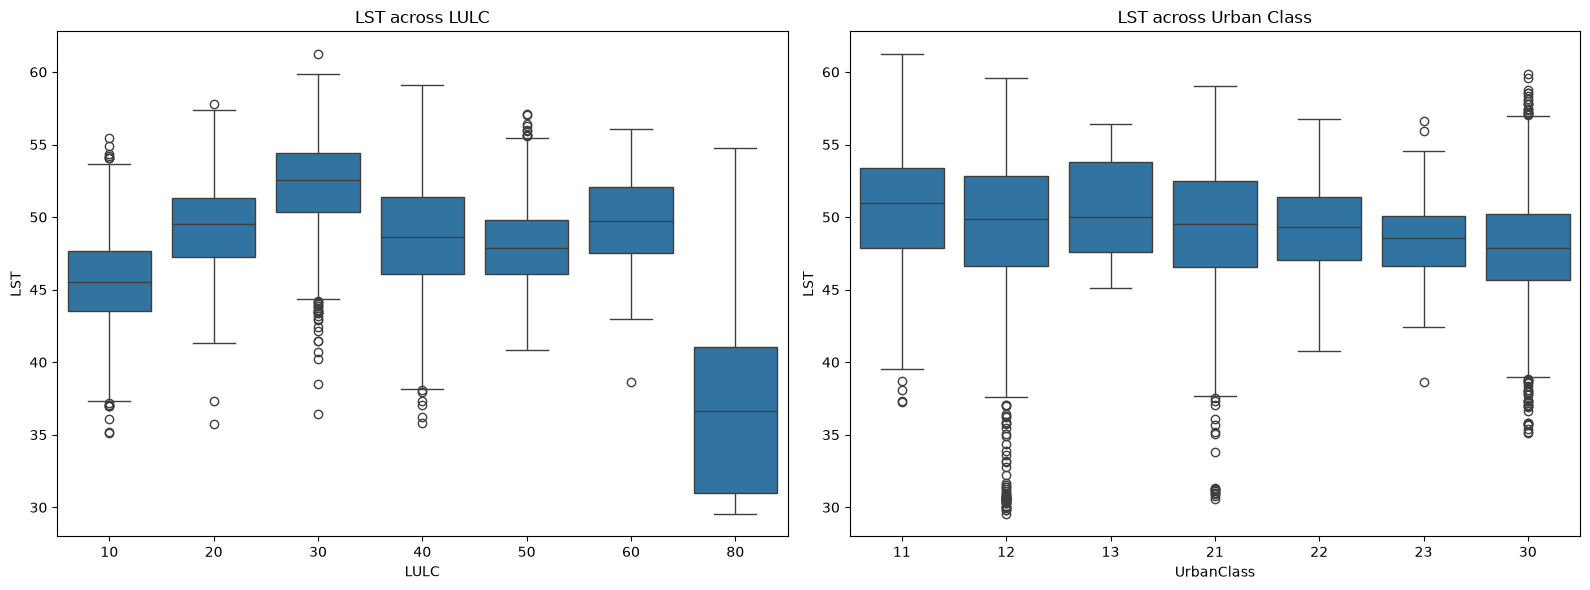

In [33]:
plt.figure(figsize=(16,6))

plt.subplot(121)
sns.boxplot(x='LULC', y='LST', data=df)
plt.title('LST across LULC')

plt.subplot(122)
sns.boxplot(x='UrbanClass', y='LST', data=df)
plt.title('LST across Urban Class')

plt.tight_layout()
plt.show()

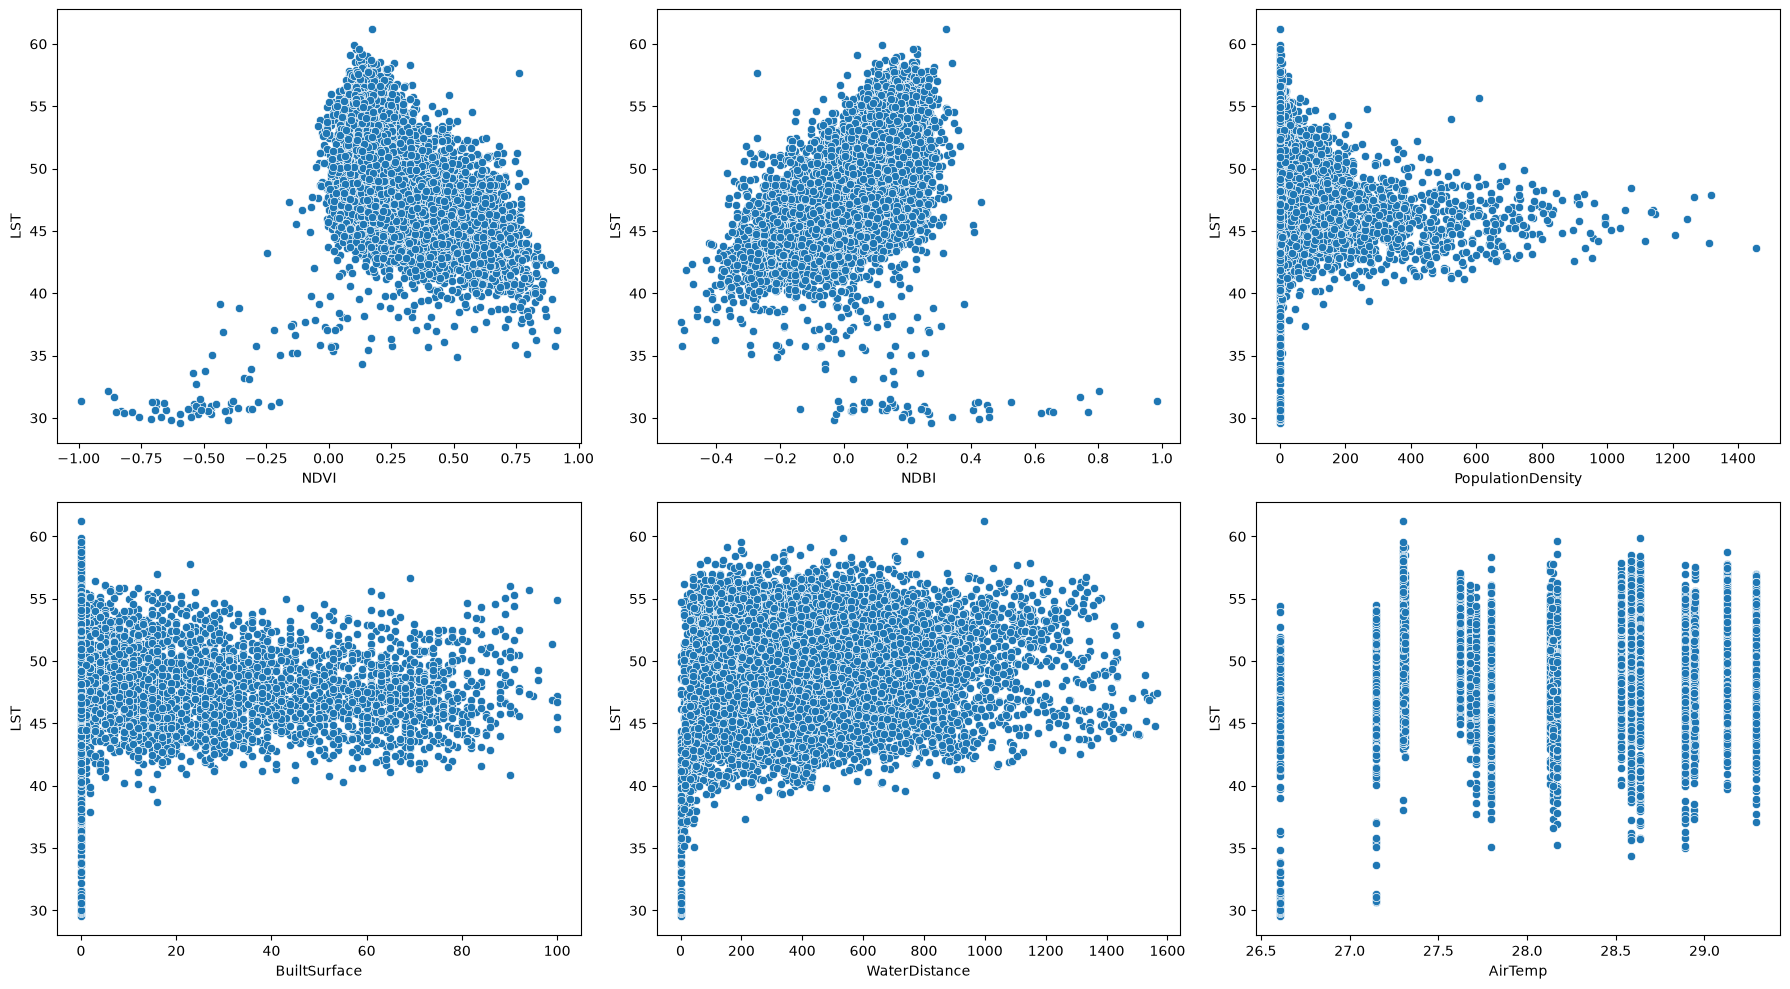

In [35]:
plt.figure(figsize=(18,10))

plt.subplot(231)
sns.scatterplot(x='NDVI', y='LST', data=df)

plt.subplot(232)
sns.scatterplot(x='NDBI', y='LST', data=df)

plt.subplot(233)
sns.scatterplot(x='PopulationDensity', y='LST', data=df)

plt.subplot(234)
sns.scatterplot(x='BuiltSurface', y='LST', data=df)

plt.subplot(235)
sns.scatterplot(x='WaterDistance', y='LST', data=df)

plt.subplot(236)
sns.scatterplot(x='AirTemp', y='LST', data=df)

plt.tight_layout()
plt.show()

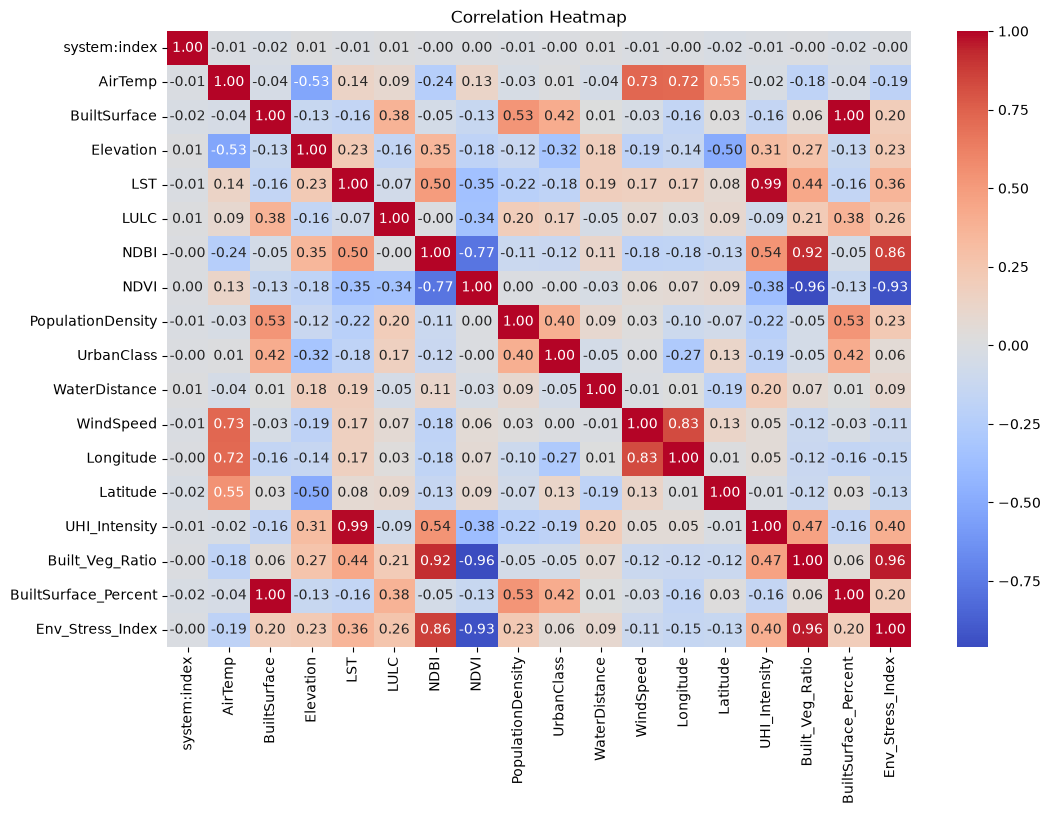

In [37]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

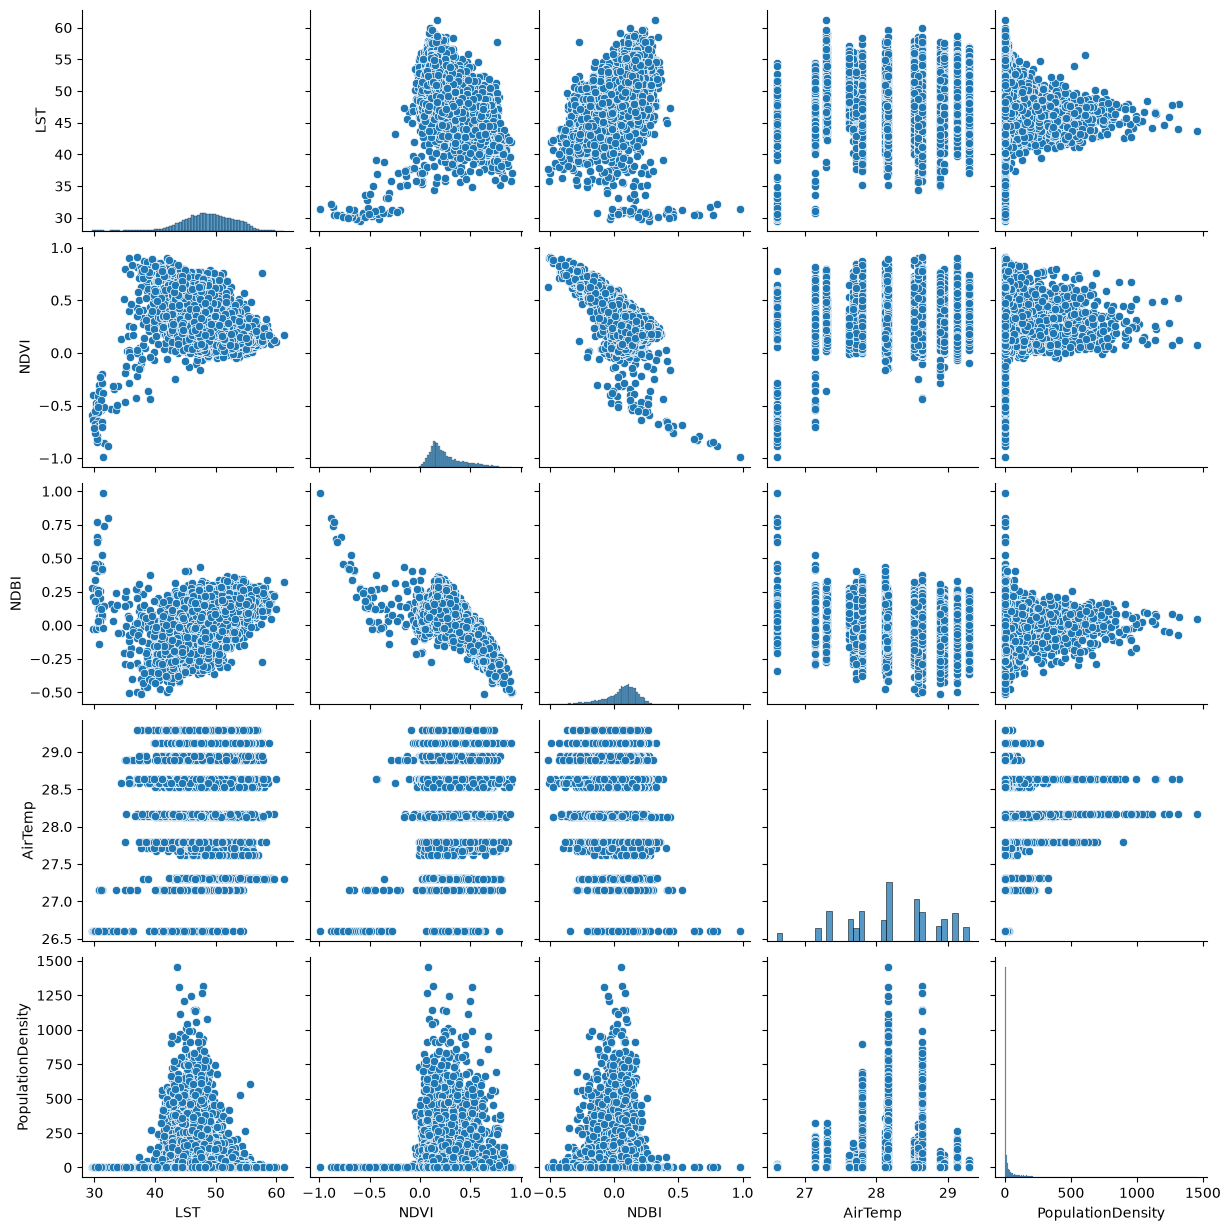

In [38]:
sns.pairplot(
    df[['LST',
        'NDVI',
        'NDBI',
        'AirTemp',
        'PopulationDensity']]
)

plt.show()